# **Dataset Final - Tratamento Adequado e Filtros**

In [1]:
%%capture
%run "/workspaces/CEA-1/análise de dados/tratamento_das_variaveis_explicativas.ipynb"

Colocar as colunas que já estão tratadas e prontas para serem analisadas

    'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas'

In [2]:
coluna_resposta = ['cls_fin_ajustada']

colunas_explicativas = ['dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'cls_eien',  'idade_anos', 'evol_num', 'cls_compl_ajustada', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']

dados_finais = dados[coluna_resposta + colunas_explicativas]
print(dados_finais.columns.tolist())
print(f"Dimensões: {dados_finais.shape[0]} linhas × {dados_finais.shape[1]} colunas")

['cls_fin_ajustada', 'dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'cls_eien', 'idade_anos', 'evol_num', 'cls_compl_ajustada', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']
Dimensões: 1083 linhas × 64 colunas


In [ ]:
#nome_do_ficheiro = 'dados_completos.csv'

## O parâmetro index=False evita que o pandas crie uma coluna extra com os números das linhas
#dados_finais.to_csv(nome_do_ficheiro, index=False, encoding='utf-8')

## Qui Quadrado Padrão

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Definir a variável resposta
resposta = 'cls_fin_ajustada'

# 3. Função matemática para calcular o V de Cramér com correção de viés
def cramers_v(tabela_contingencia):
    chi2 = chi2_contingency(tabela_contingencia, correction=False)[0]
    n = tabela_contingencia.sum().sum()
    phi2 = chi2 / n
    r, k = tabela_contingencia.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    # Evitar divisão por zero caso a matriz seja muito pequena após correção
    denominador = min((kcorr-1), (rcorr-1))
    if denominador == 0:
        return 0.0
    return np.sqrt(phi2corr / denominador)

# 4. Loop para rodar os testes em todas as variáveis
resultados = []

for col in colunas_explicativas:
    # Cria a tabela de contingência cruzando a variável com o desfecho
    # O dropna=True garante que não testaremos valores nulos
    tabela = pd.crosstab(dados_finais[col], dados_finais[resposta], dropna=True)
    
    # Se uma variável tiver apenas 1 categoria nos dados limpos, o teste falha. Pulamos ela.
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        continue
        
    # Executa o Qui-quadrado
    chi2_stat, p_valor, dof, valores_esperados = chi2_contingency(tabela)
    
    # Executa o V de Cramér
    v_cramer = cramers_v(tabela.values)
    
    # Salva o resultado no dicionário
    resultados.append({
        'Variável': col,
        'P-Valor': p_valor,
        'Significativo (p < 0.05)': 'Sim' if p_valor < 0.05 else 'Não',
        'V de Cramér': round(v_cramer, 4),
        'Força da Associação': (
            'Forte' if v_cramer >= 0.50 else
            'Moderada' if v_cramer >= 0.30 else
            'Fraca' if v_cramer >= 0.10 else
            'Insignificante'
        )
    })

# 5. Converter para DataFrame e ordenar do p-valor mais forte (menor) para o mais fraco
df_resultados_estatisticos = pd.DataFrame(resultados)
df_resultados_estatisticos = df_resultados_estatisticos.sort_values(by='P-Valor').reset_index(drop=True)

# Formatando o P-valor para notação científica bonita no print
df_resultados_estatisticos['P-Valor'] = df_resultados_estatisticos['P-Valor'].apply(lambda x: f"{x:.4e}")

print("=== Resultados da Análise Bivariada (Qui-Quadrado e V de Cramér) ===")
print(df_resultados_estatisticos.to_string())

# Dica: Para salvar no Excel e colocar na sua dissertação
# df_resultados_estatisticos.to_excel("resultados_qui_quadrado.xlsx", index=False)

=== Resultados da Análise Bivariada (Qui-Quadrado e V de Cramér) ===
                    Variável      P-Valor Significativo (p < 0.05)  V de Cramér Força da Associação
0            cls_ei_ajustada  1.2724e-210                      Sim       0.4999            Moderada
1         cls_compl_ajustada  9.8649e-169                      Sim       0.4513            Moderada
2                     tp_med  7.5818e-145                      Sim       0.5638               Forte
3   manifestacoes_sistemicas  4.0943e-132                      Sim       0.7524               Forte
4                   cls_eien  1.9108e-124                      Sim       0.3928            Moderada
5            tp_atd_ajustada  7.8816e-122                      Sim       0.5181               Forte
6       manifestacoes_locais   1.1646e-73                      Sim       0.5624               Forte
7                  convulsao   4.6997e-49                      Sim       0.4591            Moderada
8                        dor   

## Com ajustes

Frequência da Variável Resposta:
cls_fin_ajustada
EANG                   48.85%
EI                     45.98%
EAG                     4.06%
Inclassificável         0.74%
EI - evento adverso     0.37%
Name: proportion, dtype: str

RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)
                Variável  V de Cramer       P-Valor
manifestacoes_sistemicas     0.754507 4.094255e-132
                  tp_med     0.566549 7.581774e-145
    manifestacoes_locais     0.565385  1.164588e-73
         tp_atd_ajustada     0.521134 7.881649e-122
         cls_ei_ajustada     0.507252 1.272376e-210
               convulsao     0.462922  4.699706e-49
      cls_compl_ajustada     0.459595 9.864926e-169
                     dor     0.421991  1.289096e-40
                cls_eien     0.402585 1.910786e-124
                 eritema     0.373313  1.286604e-31
          guillain_barre     0.352408  4.245920e-28
                   edema     0.352358  4.326824e-28
                   febre     0.328257  2.71

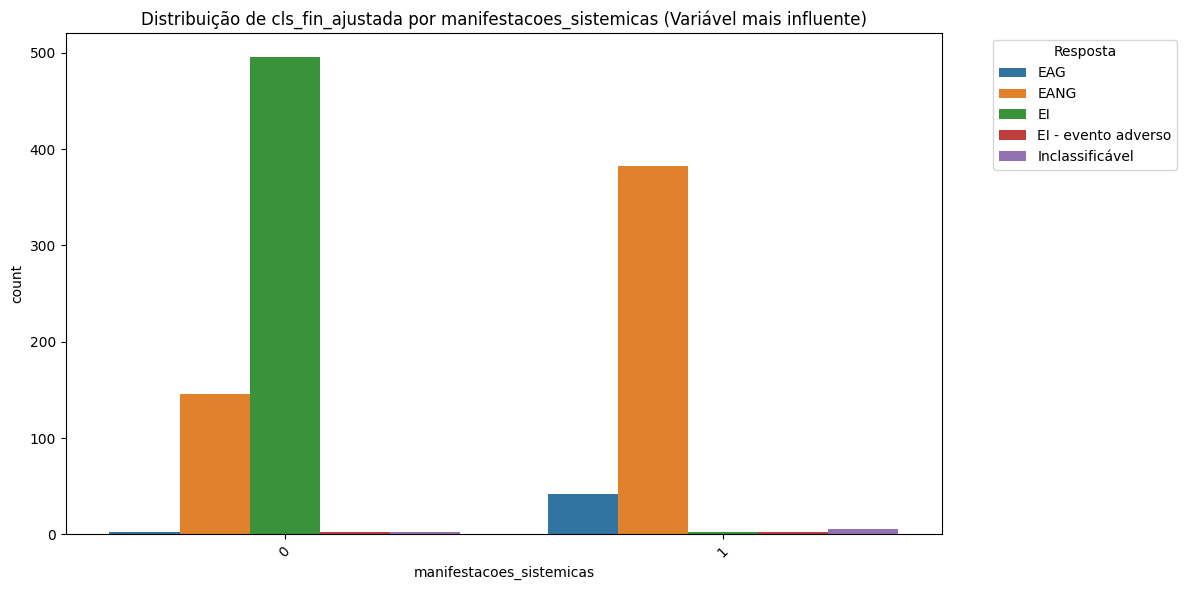

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. DEFINIÇÃO DAS COLUNAS ──────────────────────────────────────────────────
coluna_resposta = 'cls_fin_ajustada'


# Criar cópia para análise
df_analise = dados_finais.copy()

# ── 2. TRANSFORMAÇÃO PARA CATEGÓRICAS ─────────────────────────────────────────
# Convertemos para string primeiro para garantir que códigos numéricos sejam tratados como labels
for col in df_analise.columns:
    df_analise[col] = df_analise[col].astype(str).astype('category')

print("Frequência da Variável Resposta:")
print(df_analise[coluna_resposta].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# ── 3. ANÁLISE ESTATÍSTICA (ASSOCIAÇÃO) ───────────────────────────────────────
resultados = []

for col in colunas_explicativas:
    # Criar tabela de contingência
    tab_cont = pd.crosstab(df_analise[col], df_analise[coluna_resposta])
    
    # Teste Qui-Quadrado (Independência)
    chi2, p_valor, dof, ex = stats.chi2_contingency(tab_cont)
    
    # Cálculo do V de Cramer (Força da associação de 0 a 1)
    n = tab_cont.sum().sum()
    min_dim = min(tab_cont.shape) - 1
    
    if min_dim > 0 and n > 0:
        v_cramer = np.sqrt(chi2 / (n * min_dim))
    else:
        v_cramer = 0
        
    resultados.append({
        'Variável': col,
        'P-Valor': p_valor,
        'V de Cramer': v_cramer,
        'Graus de Liberdade': dof
    })

# Criar DataFrame de resultados e ordenar pela força da associação
df_stats = pd.DataFrame(resultados).sort_values(by='V de Cramer', ascending=False)

# ── 4. EXIBIÇÃO DOS RESULTADOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)")
print("="*50)
print(df_stats[['Variável', 'V de Cramer', 'P-Valor']].to_string(index=False))

# ── 5. VISUALIZAÇÃO DA TOP VARIÁVEL ──────────────────────────────────────────
top_var = df_stats.iloc[0]['Variável']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_analise, x=top_var, hue=coluna_resposta)
plt.title(f"Distribuição de {coluna_resposta} por {top_var} (Variável mais influente)")
plt.xticks(rotation=45)
plt.legend(title='Resposta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Filtros para regressão logística:**


In [6]:
# 1. Criar uma cópia para preservar os dados originais
df_filtrado = dados_finais.copy()

df_filtrado = df_filtrado[
    (df_filtrado['dt_not_ano'] != 2023) &
    (~df_filtrado['pais_nasc'].isin(['VENEZUELA', 'PERU', 'OUTROS PAISES'])) &
    (~df_filtrado['cor'].isin(['Indígena'])) &
    (df_filtrado['gestante'] != 'Sim') &
    (~df_filtrado['dt_apl_ano'].isin([2006, 2023, 2014, 2016, 2015])) &
    (df_filtrado['via_adm_ajustada'] != 'outros') &
    (~df_filtrado['local_aplic_ajustada'].isin(['Glúteo', 'Vasto Lateral da Coxa Esquerda', 'Vasto Lateral da Coxa Direito'])) &
    (~df_filtrado['cls_ei_ajustada'].isin(['A3.1', 'A3.3', 'A3.7', 'A3.8'])) &
    (~df_filtrado['cls_eien'].isin(['A3.1', 'A3.3', 'A3.2', 'A3.6'])) &
    (~df_filtrado['evol_num'].isin(['Perda de seguimento']))
]

# 3. Validar os resultados
print(f"Dimensões originais: {dados_finais.shape}")
print(f"Dimensões após filtros: {df_filtrado.shape}")

# Exemplo de verificação rápida para uma das colunas
print("\nVerificação 'pais_nasc' após filtro:")
print(df_filtrado['pais_nasc'].value_counts())

Dimensões originais: (1083, 64)
Dimensões após filtros: (1037, 64)

Verificação 'pais_nasc' após filtro:
pais_nasc
BRASIL           898
nao informado    139
Name: count, dtype: int64


In [7]:
# Lista de valores que retornam True
targets_true = ['EANG', 'EAG']

df_filtrado = df_filtrado[df_filtrado['cls_fin_ajustada'] != 'Inclassificável']
# Cria a nova variável comparando com a lista
df_filtrado['cls_fin_reg_logistica'] = df_filtrado['cls_fin_ajustada'].isin(targets_true)

# Verificação rápida da distribuição
print(df_filtrado['cls_fin_reg_logistica'].value_counts())

cls_fin_reg_logistica
True     549
False    481
Name: count, dtype: int64


In [ ]:
#nome_do_ficheiro = 'dados_filtrados.csv'

## O parâmetro index=False evita que o pandas crie uma coluna extra com os números das linhas
#df_filtrado.to_csv(nome_do_ficheiro, index=False, encoding='utf-8')

In [9]:
# Iterar por todas as colunas do dataframe filtrado
for col in df_filtrado.columns:
    print(f"\n{'='*40}")
    print(f"COLUNA: {col}")
    print(f"{'='*40}")
    
    # Calcular contagem absoluta
    contagem = df_filtrado[col].value_counts()
    
    # Calcular porcentagem (normalize=True)
    porcentagem = df_filtrado[col].value_counts(normalize=True).mul(100).round(2)
    
    # Combinar os dois em um DataFrame para exibição limpa
    resumo = pd.DataFrame({
        'Frequência': contagem,
        'Porcentagem (%)': porcentagem.astype(str) + '%'
    })
    
    print(resumo)


COLUNA: cls_fin_ajustada
                     Frequência Porcentagem (%)
cls_fin_ajustada                               
EANG                        508          49.32%
EI                          477          46.31%
EAG                          41           3.98%
EI - evento adverso           4           0.39%

COLUNA: dt_not_ano
            Frequência Porcentagem (%)
dt_not_ano                            
2018               315          30.58%
2019               283          27.48%
2020               263          25.53%
2021               122          11.84%
2022                47           4.56%

COLUNA: regiao
              Frequência Porcentagem (%)
regiao                                  
Sudeste              575          55.83%
Sul                  290          28.16%
Nordeste              91           8.83%
Centro-Oeste          42           4.08%
Norte                 32           3.11%

COLUNA: pais_nasc
               Frequência Porcentagem (%)
pais_nasc                    

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Definir a variável resposta
resposta = 'cls_fin_reg_logistica'

# 3. Função matemática para calcular o V de Cramér com correção de viés
def cramers_v(tabela_contingencia):
    chi2 = chi2_contingency(tabela_contingencia, correction=False)[0]
    n = tabela_contingencia.sum().sum()
    phi2 = chi2 / n
    r, k = tabela_contingencia.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    # Evitar divisão por zero caso a matriz seja muito pequena após correção
    denominador = min((kcorr-1), (rcorr-1))
    if denominador == 0:
        return 0.0
    return np.sqrt(phi2corr / denominador)

# 4. Loop para rodar os testes em todas as variáveis
resultados = []

for col in colunas_explicativas:
    # Cria a tabela de contingência cruzando a variável com o desfecho
    # O dropna=True garante que não testaremos valores nulos
    tabela = pd.crosstab(df_filtrado[col], df_filtrado[resposta], dropna=True)
    
    # Se uma variável tiver apenas 1 categoria nos dados limpos, o teste falha. Pulamos ela.
    if tabela.shape[0] < 2 or tabela.shape[1] < 2:
        continue
        
    # Executa o Qui-quadrado
    chi2_stat, p_valor, dof, valores_esperados = chi2_contingency(tabela)
    
    # Executa o V de Cramér
    v_cramer = cramers_v(tabela.values)
    
    # Salva o resultado no dicionário
    resultados.append({
        'Variável': col,
        'P-Valor': p_valor,
        'Significativo (p < 0.05)': 'Sim' if p_valor < 0.05 else 'Não',
        'V de Cramér': round(v_cramer, 4),
        'Força da Associação': (
            'Forte' if v_cramer >= 0.50 else
            'Moderada' if v_cramer >= 0.30 else
            'Fraca' if v_cramer >= 0.10 else
            'Insignificante'
        )
    })

# 5. Converter para DataFrame e ordenar do p-valor mais forte (menor) para o mais fraco
df_resultados_estatisticos = pd.DataFrame(resultados)
df_resultados_estatisticos = df_resultados_estatisticos.sort_values(by='P-Valor').reset_index(drop=True)

# Formatando o P-valor para notação científica bonita no print
df_resultados_estatisticos['P-Valor'] = df_resultados_estatisticos['P-Valor'].apply(lambda x: f"{x:.4e}")

print("=== Resultados da Análise Bivariada (Qui-Quadrado e V de Cramér) ===")
print(df_resultados_estatisticos.to_string())

# Dica: Para salvar no Excel e colocar na sua dissertação
# df_resultados_estatisticos.to_excel("resultados_qui_quadrado.xlsx", index=False)

=== Resultados da Análise Bivariada (Qui-Quadrado e V de Cramér) ===
                    Variável      P-Valor Significativo (p < 0.05)  V de Cramér Força da Associação
0            cls_ei_ajustada  2.2265e-213                      Sim       0.9902               Forte
1                     tp_med  2.7218e-137                      Sim       0.7805               Forte
2                   cls_eien  1.7208e-135                      Sim       0.7931               Forte
3   manifestacoes_sistemicas  9.6972e-125                      Sim       0.7419               Forte
4         cls_compl_ajustada  3.3614e-101                      Sim       0.6882               Forte
5       manifestacoes_locais   4.6346e-72                      Sim       0.5609               Forte
6            tp_atd_ajustada   1.9623e-53                      Sim       0.4837            Moderada
7                        dor   6.0426e-40                      Sim       0.4137            Moderada
8                    eritema   

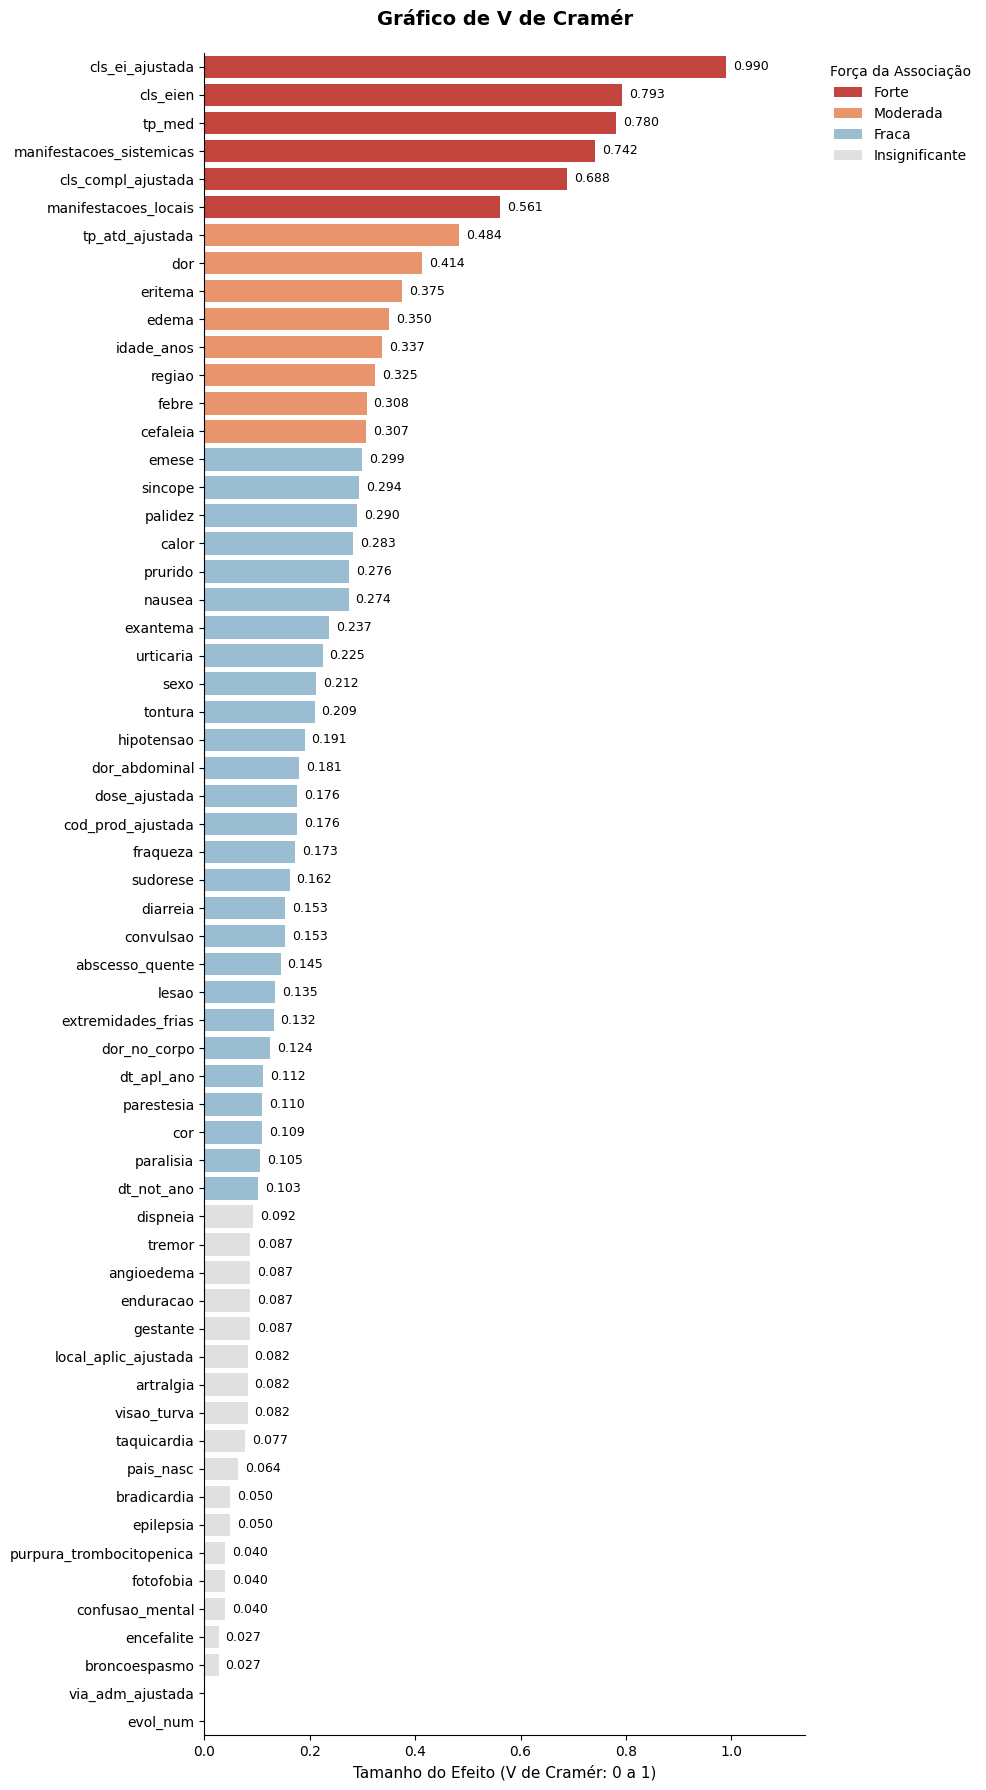

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados: ordenar pelo V de Cramér decrescente
df_plot = df_resultados_estatisticos.copy()
df_plot = df_plot.sort_values(by='V de Cramér', ascending=False)

# 2. Definir uma paleta de cores categórica (estilo acadêmico)
# Essas cores ajudam a destacar visualmente o que é importante
cores_forca = {
    'Forte': '#d73027',         # Vermelho escuro
    'Moderada': '#fc8d59',      # Laranja
    'Fraca': '#91bfdb',         # Azul claro
    'Insignificante': '#e0e0e0' # Cinza
}

# 3. Ajustar o tamanho da figura dinamicamente de acordo com o número de variáveis
altura_fig = max(8, len(df_plot) * 0.3)
fig, ax = plt.subplots(figsize=(10, altura_fig))

# 4. Criar o gráfico de barras
sns.barplot(
    data=df_plot,
    x='V de Cramér',
    y='Variável',
    hue='Força da Associação',
    palette=cores_forca,
    dodge=False, # Impede que as barras fiquem deslocadas
    ax=ax
)

# 5. Adicionar o valor numérico exato no final de cada barra
for p in ax.patches:
    largura = p.get_width()
    if largura > 0: # Apenas para barras com valor > 0
        ax.annotate(f'{largura:.3f}', 
                    (largura, p.get_y() + p.get_height() / 2),
                    ha='left', va='center',
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=9, color='black')

# 6. Estilização final para ficar com visual de artigo científico
plt.title('Gráfico de V de Cramér', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tamanho do Efeito (V de Cramér: 0 a 1)', fontsize=11)
plt.ylabel('') # Deixa o eixo Y sem título para ficar mais limpo
plt.xlim(0, max(df_plot['V de Cramér']) + 0.15) # Dá uma margem no eixo X para o texto caber

# Arruma a legenda para fora do gráfico
plt.legend(title='Força da Associação', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Remove as bordas superior e direita para um visual mais limpo
sns.despine()

plt.tight_layout()

# Salva em alta resolução para colar no Word/PowerPoint
plt.show()

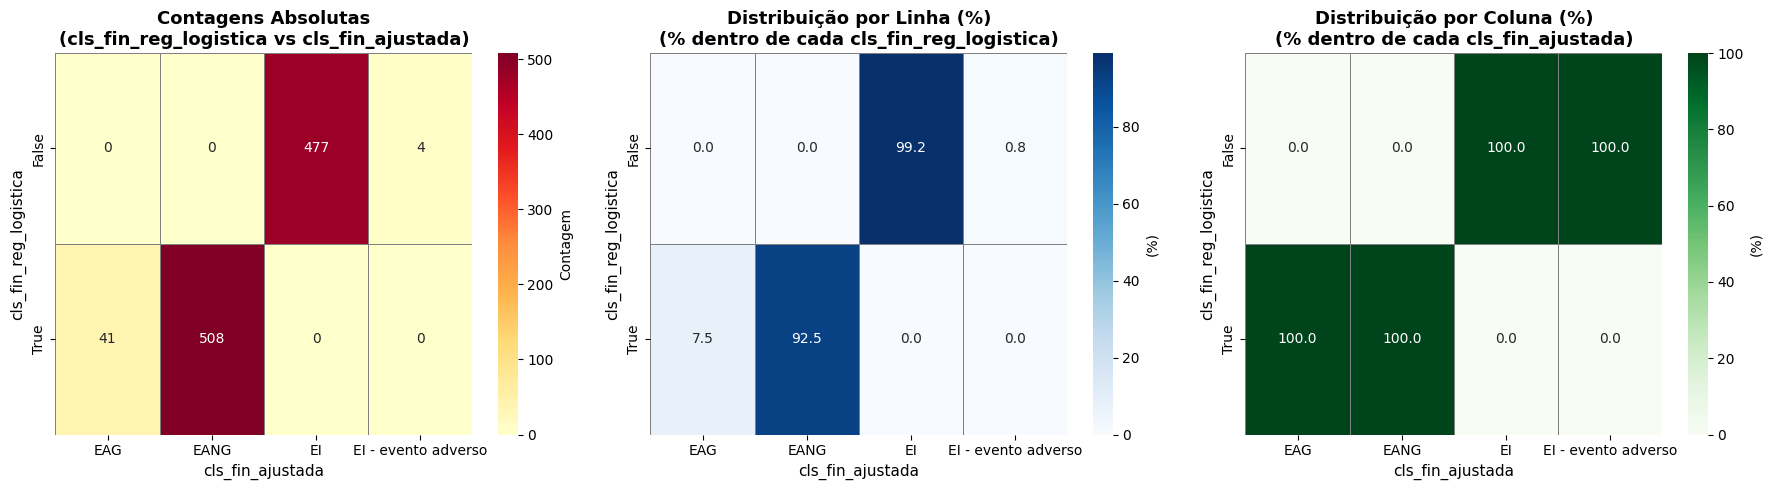

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

comparacao = 'cls_fin_ajustada'

dados_resposta = df_filtrado

contagem = pd.crosstab(dados_resposta['cls_fin_reg_logistica'], dados_resposta[comparacao])
percentual_linhas = pd.crosstab(dados_resposta['cls_fin_reg_logistica'], dados_resposta[comparacao], normalize='index') * 100
percentual_colunas = pd.crosstab(dados_resposta['cls_fin_reg_logistica'], dados_resposta[comparacao], normalize='columns') * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Contagens Absolutas\n(cls_fin_reg_logistica vs cls_fin_ajustada)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('cls_fin_ajustada', fontsize=11)
axes[0].set_ylabel('cls_fin_reg_logistica', fontsize=11)

sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Distribuição por Linha (%)\n(% dentro de cada cls_fin_reg_logistica)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('cls_fin_ajustada', fontsize=11)
axes[1].set_ylabel('cls_fin_reg_logistica', fontsize=11)

sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
            ax=axes[2], linewidths=0.5, linecolor='gray')
axes[2].set_title('Distribuição por Coluna (%)\n(% dentro de cada cls_fin_ajustada)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('cls_fin_ajustada', fontsize=11)
axes[2].set_ylabel('cls_fin_reg_logistica', fontsize=11)

plt.tight_layout()
plt.show()